In [1]:
import os, bz2
import pandas as pd
import random
import scipy
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
jan21 = dict()
with bz2.open('/shares/CIBIO-Storage/CM/scratch/databases/MetaRefSGB/releases/Jan21/SGB.Jan21.txt.bz2', 'rt') as  rf:
    for line in rf:
        if line.startswith('SGB'):
            line = line.strip().split('\t')
            jan21[line[1]] = [[x for x in line[4].split(',') if x != '-'], [x for x in line[5].split(',') if x != '-']]
        elif line.startswith('GGB'):
            break

In [3]:
jan21

{'1': [['GCA_001872325', 'GCA_002790905'], []],
 '2': [['GCA_001872185', 'GCA_002763105', 'GCA_002792685'], []],
 '4': [['GCA_002763165'], []],
 '5': [['GCA_002763075'], []],
 '8': [['GCA_002779075'], []],
 '17': [['GCA_003512705'], []],
 '19': [['GCA_002503745',
   'GCA_002688315',
   'NayfachS_2020__GEM_3300020423__bin.66',
   'ParksDH_2017__UBA142',
   'ParksDH_2017__UBA492'],
  []],
 '20': [['GCA_000830295'], []],
 '21': [['GCA_001829375', 'GCA_003497555'], []],
 '24': [['GCA_002897655', 'GCA_011050875'], []],
 '27': [['GCA_002685855'], []],
 '28': [['GCA_002688775'], []],
 '29': [['GCA_001940655'], []],
 '30': [['GCA_003663075'], []],
 '57': [['GCA_001871475', 'GCA_002499375', 'GCA_002762955'], []],
 '58': [['GCA_002779065'], []],
 '59': [['GCA_001871535', 'GCA_002778915', 'GCA_002779685', 'GCA_002792955'],
  []],
 '60': [['GCA_001871595', 'GCA_002507385', 'ParksDH_2017__UBA97'], []],
 '61': [['GCA_002763345'], []],
 '63': [['GCA_001871655',
   'GCA_002505035',
   'GCA_002763205',

In [4]:
metadata = pd.read_table('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/nw_metadata.tsv')

In [5]:
set(metadata['age_category'].tolist())

{'adult', 'child', nan, 'newborn', 'schoolage', 'senior'}

In [6]:
metadata[metadata['non_westernized'] == 'no']['country'].unique()

array(['ESP', 'ITA', 'LUX', 'FIN', 'CAN', 'USA', 'CHN', 'MNG', 'BGD',
       'DNK', 'SWE', 'AUT', 'JPN', 'IRL', 'DEU', 'GBR', 'NLD', 'FRA',
       'ISL', 'KOR', 'IND', 'RUS', 'EST', 'KAZ', 'ISR'], dtype=object)

In [7]:
nw = metadata[metadata['non_westernized'] == 'yes']

In [8]:
nw[nw['study_name'].str.contains('CM_')].groupby('country')['sample_id'].count().sum()

1008

In [9]:
nw[~nw['study_name'].str.contains('CM_')].groupby('country')['sample_id'].count().sum()

710

<AxesSubplot:>

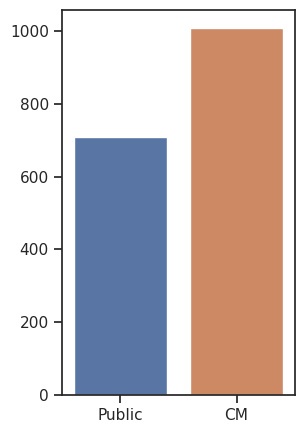

In [10]:
sns.set(font_scale=1)
sns.set_style("ticks")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = [3,5]
sns.barplot(x=['Public', 'CM'], y=[710,1008])
# plt.savefig('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/figures/public_cm_samples.svg')

In [11]:
nw_samples = nw['study_name'] + '__' + nw['sample_id'] + '__' 
nw_samples = nw_samples.tolist()
nw_samples

['LiuW_2016__SRR3992958__',
 'LiuW_2016__SRR3992959__',
 'LiuW_2016__SRR3992960__',
 'LiuW_2016__SRR3992961__',
 'LiuW_2016__SRR3992962__',
 'LiuW_2016__SRR3992963__',
 'LiuW_2016__SRR3992964__',
 'LiuW_2016__SRR3992965__',
 'LiuW_2016__SRR3992966__',
 'LiuW_2016__SRR3992967__',
 'LiuW_2016__SRR3992991__',
 'LiuW_2016__SRR3992992__',
 'LiuW_2016__SRR3992993__',
 'LiuW_2016__SRR3992994__',
 'LiuW_2016__SRR3992995__',
 'LiuW_2016__SRR3992996__',
 'LiuW_2016__SRR3992997__',
 'LiuW_2016__SRR3992998__',
 'LiuW_2016__SRR3993000__',
 'LiuW_2016__SRR3993001__',
 'LiuW_2016__SRR3993002__',
 'LiuW_2016__SRR3993003__',
 'LiuW_2016__SRR3993004__',
 'LiuW_2016__SRR3993005__',
 'LiuW_2016__SRR3993006__',
 'LiuW_2016__SRR3993007__',
 'LiuW_2016__SRR3993008__',
 'LiuW_2016__SRR3993009__',
 'LiuW_2016__SRR3993025__',
 'LiuW_2016__SRR3993026__',
 'LiuW_2016__SRR3993027__',
 'LiuW_2016__SRR3993028__',
 'LiuW_2016__SRR3993029__',
 'LiuW_2016__SRR3993030__',
 'LiuW_2016__SRR3993031__',
 'LiuW_2016__SRR3993

In [12]:
nw_studies = list(set(nw['study_name'].tolist()))
nw_studies

['BritoIL_2016',
 'CM_ghana',
 'CM_tanzania2',
 'RubelMA_2020',
 'PehrssonE_2016',
 'CM_tanzania',
 'RampelliS_2015',
 'CM_guinea2',
 'LokmerA_2019',
 'RosaBA_2018',
 'CM_ghana2',
 'CM_madagascar',
 'Obregon-TitoAJ_2015',
 'CM_china',
 'SmitsSA_2017',
 'CM_guinea',
 'CM_ethiopia',
 'KaurK_2020',
 'CM_tanzania_TB_DAR',
 'CM_argentina',
 'CM_colombia',
 'LiuW_2016']

In [13]:
project_to_SGBs = dict()
sgbs2number = dict()
for s in nw_studies:
    project_to_SGBs[s] = list()
    for sgb in jan21:
        for y in [x.split('__')[0] + '__' + x.split('__')[1] + '__' for x in jan21[sgb][0] if len(x.split('__')) > 1 and x.split('__')[0] == s]:
            if y in nw_samples:
                project_to_SGBs[s].append(sgb)
                if sgb not in sgbs2number:
                    sgbs2number[sgb] = 0
                sgbs2number[sgb] += 1
                break

In [14]:
project2unique = dict()
for p in project_to_SGBs:
    project2unique[p] = 0
    for s in project_to_SGBs[p]:
        if sgbs2number[s] == 1:
            project2unique[p] += 1
project2unique = {k: v for k, v in sorted(project2unique.items(), key=lambda item: item[1], reverse=True)}
project2unique

{'CM_tanzania_TB_DAR': 385,
 'CM_guinea2': 273,
 'CM_argentina': 105,
 'BritoIL_2016': 77,
 'CM_guinea': 74,
 'CM_tanzania': 58,
 'RubelMA_2020': 51,
 'CM_madagascar': 49,
 'CM_ethiopia': 49,
 'LokmerA_2019': 47,
 'CM_tanzania2': 43,
 'LiuW_2016': 43,
 'PehrssonE_2016': 38,
 'Obregon-TitoAJ_2015': 38,
 'CM_ghana': 31,
 'CM_china': 31,
 'CM_ghana2': 30,
 'KaurK_2020': 23,
 'CM_colombia': 22,
 'RampelliS_2015': 20,
 'SmitsSA_2017': 5,
 'RosaBA_2018': 0}

In [15]:
nw_enrichment = dict()
i = 0
nw_enrichment[0] = set()
for s in project2unique.keys():
    i += 1
    nw_enrichment[i] = nw_enrichment[i-1].copy()
    for sgb in jan21:
        for y in [x.split('__')[0] + '__' + x.split('__')[1] + '__' for x in jan21[sgb][0] if len(x.split('__')) > 1 and x.split('__')[0] == s]:
            if y in nw_samples:
                nw_enrichment[i].add(sgb)
                break

In [16]:
k_enrichment = dict()
i = 0
k_enrichment[0] = set()
u_enrichment = dict()
u_enrichment[0] = set()
u5_enrichment = dict()
u5_enrichment[0] = set()
for s in project2unique.keys():
    i += 1
    k_enrichment[i] = k_enrichment[i-1].copy()
    u_enrichment[i] = u_enrichment[i-1].copy()
    u5_enrichment[i] = u5_enrichment[i-1].copy()
    for sgb in jan21:
        for y in [x.split('__')[0] + '__' + x.split('__')[1] + '__' for x in jan21[sgb][0] if len(x.split('__')) > 1 and x.split('__')[0] == s]:
            if y in nw_samples:
                if len(jan21[sgb][1]) == 0:
                    u_enrichment[i].add(sgb)
                    if len(jan21[sgb][0]) >= 5:
                        u5_enrichment[i].add(sgb)
                else:
                    k_enrichment[i].add(sgb)                    
                break
            

In [17]:
datasets2sgbs = { i: len(nw_enrichment[i]) for i in nw_enrichment }
k_datasets2sgbs = { i: len(k_enrichment[i]) for i in k_enrichment }
u_datasets2sgbs = { i: len(u_enrichment[i]) for i in u_enrichment }
u5_datasets2sgbs = { i: len(u5_enrichment[i]) for i in u5_enrichment }

In [18]:
df = pd.concat([pd.DataFrame(datasets2sgbs.keys()), pd.DataFrame(datasets2sgbs.values())], axis=1)
df.columns = ['Number of non-Westernized datasets', 'Number of SGBs']
df['SGB type'] = 'All'
df
dfk = pd.concat([pd.DataFrame(k_datasets2sgbs.keys()), pd.DataFrame(k_datasets2sgbs.values())], axis=1)
dfk.columns = ['Number of non-Westernized datasets', 'Number of SGBs']
dfk['SGB type'] = 'kSGBs'
dfk
dfu = pd.concat([pd.DataFrame(u_datasets2sgbs.keys()), pd.DataFrame(u_datasets2sgbs.values())], axis=1)
dfu.columns = ['Number of non-Westernized datasets', 'Number of SGBs']
dfu['SGB type'] = 'uSGBs'
dfu5 = pd.concat([pd.DataFrame(u5_datasets2sgbs.keys()), pd.DataFrame(u5_datasets2sgbs.values())], axis=1)
dfu5.columns = ['Number of non-Westernized datasets', 'Number of SGBs']
dfu5['SGB type'] = 'uSGBs >= 5 MAGs'
df_f = pd.concat([df, dfk, dfu, dfu5], axis=0)
df_f

,Number of non-Westernized datasets,Number of SGBs,SGB type
0,0,0,All
1,1,1034,All
2,2,1631,All
3,3,1804,All
4,4,1993,All
...,...,...,...
18,18,742,uSGBs >= 5 MAGs
19,19,743,uSGBs >= 5 MAGs
20,20,748,uSGBs >= 5 MAGs
21,21,749,uSGBs >= 5 MAGs


<AxesSubplot:xlabel='Number of non-Westernized datasets', ylabel='Number of SGBs'>

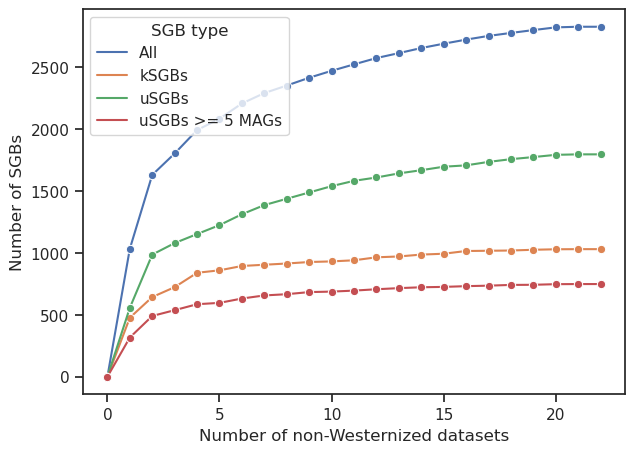

In [19]:
sns.set(font_scale=1)
sns.set_style("ticks")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = [7,5]
sns.lineplot(x="Number of non-Westernized datasets", y="Number of SGBs", hue='SGB type', marker="o", data=df_f.reset_index(drop=True))
# plt.savefig('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/figures/SGB_enrichment.svg')

In [20]:
cm_samples=nw[nw['study_name'].str.contains('CM_')]['sample_id'].tolist()
public_samples=nw[~ nw['study_name'].str.contains('CM_')]['sample_id'].tolist()

In [21]:
cm = 0
public = 0
for sgb in jan21:
    for y in [x.split('__')[1] for x in jan21[sgb][0] if len(x.split('__')) > 1]:
        if y in cm_samples:
            cm += 1
        elif y in public_samples:
            public += 1

In [22]:
cm

22625

In [23]:
public

12260

<AxesSubplot:>

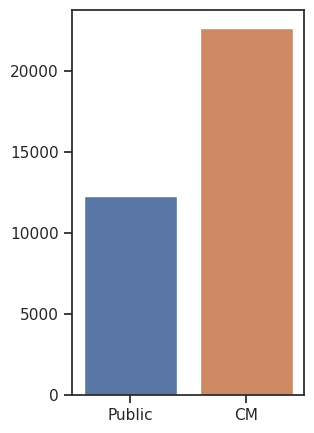

In [24]:
sns.set(font_scale=1)
sns.set_style("ticks")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = [3,5]
sns.barplot(x=['Public', 'CM'], y=[12260,22625])
# plt.savefig('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/figures/public_cm_mags.svg')

In [25]:
mags_counts = {k:[0,''] for k in cm_samples+public_samples}
for sgb in jan21:
    for y in [x.split('__')[1] for x in jan21[sgb][0] if len(x.split('__')) > 1]:
        if y in cm_samples:
            mags_counts[y][0] += 1
            mags_counts[y][1] = 'CM'
        elif y in public_samples:
            mags_counts[y][0] += 1
            mags_counts[y][1] = 'Public'


In [26]:
mags_counts = {k:v for k,v in mags_counts.items() if v[0] > 0}

In [27]:
mags_pd = pd.DataFrame.from_dict(mags_counts).transpose()
mags_pd.columns = ['Number of MAGs', 'Source']
mags_pd

,Number of MAGs,Source
CM_A01_I1_18,35,CM
CM_A01_M0_18,36,CM
CM_A04_I1_18,5,CM
CM_A04_M0_18,16,CM
CM_A06_I1_18,16,CM
...,...,...
SID01H_011,2,Public
SID01A_006,2,Public
SID040204,1,Public
SID060502,2,Public


TypeError: ufunc 'isnan' not supported for the input types, and the inputs could not be safely coerced to any supported types according to the casting rule ''safe''

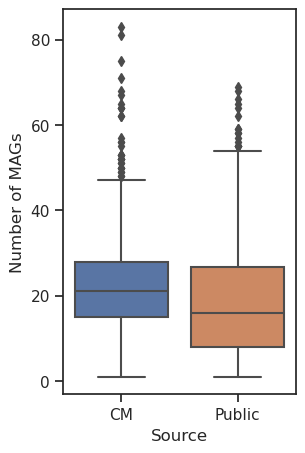

In [28]:
sns.boxplot(x="Source", y="Number of MAGs", data=mags_pd)
print(scipy.stats.mannwhitneyu(mags_pd.loc[mags_pd['Source']=='Public']['Number of MAGs'], mags_pd.loc[mags_pd['Source']=='CM']['Number of MAGs'], alternative='two-sided'))

In [29]:
sample2sgbs = dict()
included_nw_samples = set()
for s in project2unique.keys():
    for sgb in jan21:
        for y in [x.split('__')[0] + '__' + x.split('__')[1] + '__' for x in jan21[sgb][0] if len(x.split('__')) > 1 and x.split('__')[0] == s]:
            if y in nw_samples:
                included_nw_samples.add(y)            
                if y not in sample2sgbs:
                    sample2sgbs[y] = set()                
                sample2sgbs[y].add(sgb)
print(len(included_nw_samples))
print(len(sample2sgbs))

1650
1650


In [30]:
included_nw_samples

{'CM_argentina__ARG_B5__',
 'CM_guinea__GUI_0210105__',
 'CM_guinea__GUI_0140308__',
 'CM_tanzania2__C16-20096-TZ__',
 'CM_guinea2__GUI_180304__',
 'CM_guinea2__GUI_150119__',
 'CM_tanzania__C16-20374-TZ__',
 'CM_guinea2__GUI_200109__',
 'CM_guinea2__GUI_200410__',
 'PehrssonE_2016__SID210401__',
 'CM_guinea2__GUI_130105__',
 'CM_china__CHN_2D2__',
 'CM_madagascar__A42_02_1FE__',
 'CM_colombia__COL_6MH__',
 'CM_tanzania__C16-20215-TZ__',
 'CM_ghana2__C16-20402-GH__',
 'CM_tanzania_TB_DAR__83431_31__',
 'BritoIL_2016__W2.61.ST__',
 'CM_ghana2__C16-20039-GH__',
 'BritoIL_2016__W2.67.ST__',
 'CM_ghana2__C16-20286-GH__',
 'RampelliS_2015__H17__',
 'CM_tanzania_TB_DAR__83426_31__',
 'LokmerA_2019__SAMEA4719784__',
 'CM_tanzania2__C16-20368-TZ__',
 'CM_tanzania_TB_DAR__83479_31__',
 'SmitsSA_2017__TZ_93321__',
 'CM_madagascar__A90_03_1FE__',
 'CM_ethiopia__CM_D43_I1_18__',
 'BritoIL_2016__W1.34.ST__',
 'CM_ghana__C16-20247-GH__',
 'CM_madagascar__A47_01_1FE__',
 'RampelliS_2015__H15__',
 'CM

In [31]:
enr_res = list()
for i in range(1, len(included_nw_samples) + 1):
    for n in range(0,99):
        enrichment = set()
        u_enrichment = set()
        u5_enrichment = set()
        k_enrichment = set()
        for sample in random.sample(included_nw_samples, i):
            for sgb in sample2sgbs[sample]:
                enrichment.add(sgb)
                if len(jan21[sgb][1]) == 0:
                    u_enrichment.add(sgb)
                    if len(jan21[sgb][0]) >= 5:
                        u5_enrichment.add(sgb)
                else:
                    k_enrichment.add(sgb)
                
        enr_res.append([i, len(enrichment), 'All'])
        enr_res.append([i, len(k_enrichment), 'kSGBs'])
        enr_res.append([i, len(u_enrichment), 'uSGBs'])
        enr_res.append([i, len(u5_enrichment), 'uSGBs >= 5 MAGs'])

In [32]:
df_f = pd.DataFrame(enr_res)
df_f.columns = ['Number of non-Westernized samples','Number of SGBs','SGB type']
df_f

,Number of non-Westernized samples,Number of SGBs,SGB type
0,1,1,All
1,1,1,kSGBs
2,1,0,uSGBs
3,1,0,uSGBs >= 5 MAGs
4,1,38,All
...,...,...,...
653395,1650,749,uSGBs >= 5 MAGs
653396,1650,2828,All
653397,1650,1031,kSGBs
653398,1650,1797,uSGBs


<AxesSubplot:xlabel='Number of non-Westernized samples', ylabel='Number of SGBs'>

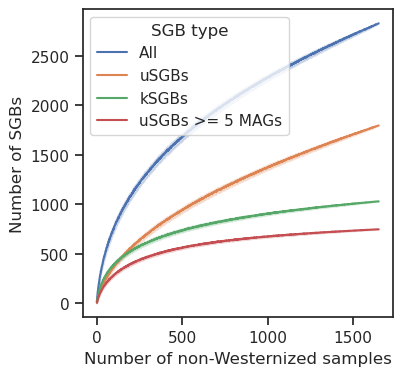

In [33]:
sns.set(font_scale=1)
sns.set_style("ticks")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = [4,4]
sns.lineplot(x="Number of non-Westernized samples", y="Number of SGBs", hue='SGB type', hue_order=['All', 'uSGBs','kSGBs','uSGBs >= 5 MAGs'], data=df_f, ci='sd')
# plt.savefig('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/figures/SGB_enrichment_samples.svg')

In [34]:
w = metadata[metadata['non_westernized'] == 'no']
w_samples = w['study_name'] + '__' + w['sample_id'] + '__' 
w_samples = w_samples.tolist()
w_samples

['NielsenHB_2014__O2_UC49_0__',
 'NielsenHB_2014__O2_UC49_2__',
 'NielsenHB_2014__O2_UC50_0__',
 'NielsenHB_2014__O2_UC50_2__',
 'NielsenHB_2014__O2_UC51_0__',
 'NielsenHB_2014__O2_UC51_2__',
 'NielsenHB_2014__O2_UC52_0__',
 'NielsenHB_2014__O2_UC52_2__',
 'NielsenHB_2014__O2_UC53_0__',
 'NielsenHB_2014__O2_UC53_2__',
 'NielsenHB_2014__O2_UC54_0__',
 'NielsenHB_2014__O2_UC54_2__',
 'NielsenHB_2014__O2_UC55_0__',
 'NielsenHB_2014__O2_UC55_2__',
 'NielsenHB_2014__O2_UC56_0__',
 'NielsenHB_2014__O2_UC56_2__',
 'NielsenHB_2014__O2_UC57_0__',
 'NielsenHB_2014__O2_UC57_2__',
 'NielsenHB_2014__O2_UC58_0__',
 'NielsenHB_2014__O2_UC58_2__',
 'NielsenHB_2014__O2_UC59_0__',
 'NielsenHB_2014__O2_UC59_2__',
 'NielsenHB_2014__O2_UC60_0__',
 'NielsenHB_2014__O2_UC60_2__',
 'NielsenHB_2014__V1_CD11_0__',
 'NielsenHB_2014__V1_CD13_0__',
 'NielsenHB_2014__V1_CD14_0__',
 'NielsenHB_2014__V1_CD16_0__',
 'NielsenHB_2014__V1_CD19_0__',
 'NielsenHB_2014__V1_CD2_0__',
 'NielsenHB_2014__V1_CD22_0__',
 'Nielsen

In [35]:
w_studies = list(set(w['study_name'].tolist()))
w_studies

['AsnicarF_2021',
 'SankaranarayananK_2015',
 'ZhuF_2020',
 'KieserS_2018',
 'KeohaneDM_2020',
 'HansenLBS_2018',
 'NielsenHB_2014',
 'YassourM_2018',
 'HallAB_2017',
 'LiJ_2014',
 'KarlssonFH_2013',
 'YeZ_2018',
 'ZeeviD_2015',
 'ShaoY_2019',
 'ChuDM_2017',
 'ZellerG_2014',
 'IjazUZ_2017',
 'LiSS_2016',
 'RampelliS_2015',
 'RaymondF_2016',
 'HanniganGD_2017',
 'FengQ_2015',
 'HMP_2019_t2d',
 'SchirmerM_2016',
 'VatanenT_2016',
 'JieZ_2017',
 'Heitz-BuschartA_2016',
 'GuptaA_2019',
 'HMP_2012',
 'VogtmannE_2016',
 'WampachL_2018',
 'LifeLinesDeep_2016',
 'NagySzakalD_2017',
 'MehtaRS_2018',
 'DhakanDB_2019',
 'YuJ_2015',
 'YachidaS_2019',
 'LeChatelierE_2013',
 'QinJ_2012',
 'BrooksB_2017',
 'LawrenceA_2015',
 'CM_caritro',
 'LouisS_2016',
 'AsnicarF_2017',
 'Obregon-TitoAJ_2015',
 'ThomasAM_2019_a',
 'YassourM_2016',
 'HMP_2019_ibdmdb',
 'ThomasAM_2019_c',
 'LiJ_2017',
 'QinN_2014',
 'XieH_2016',
 'BengtssonPalmeJ_2015',
 'DeFilippisF_2019',
 'WirbelJ_2018',
 'BackhedF_2015',
 'LiuW_2

In [36]:
w_studies = list(set(w['study_name'].tolist()))
aux = set()
for x in w_studies:
    if x.startswith('ThomasAM_2019_a'):
        x = 'ThomasAM_2019'
    elif x.startswith('ThomasAM_2019_b'):
        x = 'ThomasAM_2019'
    elif x.startswith('ThomasAM_2019_c'):
        x = 'ThomasAM_2019'
    elif x.startswith('BengtssonPalmeJ_2015'):
        x = 'Bengtsson-PalmeJ_2015'
    elif x.startswith('Heitz-BuschartA_2016'):
        x = 'Heitz-BuschartA_2016'
    elif x.startswith('CM_caritro'):
        x = 'FerrettiP_2018'
    elif x.startswith('LawrenceA_2015'):
        x = 'DavidLA_2015'
    aux.add(x)
w_studies = list(aux)

w = metadata[metadata['non_westernized'] == 'no']
w_samples = w['study_name'].str.replace('ThomasAM_2019_a', 'ThomasAM_2019').replace('ThomasAM_2019_b', 'ThomasAM_2019').replace('ThomasAM_2019_c', 'ThomasAM_2019').replace('BengtssonPalmeJ_2015', 'Bengtsson-PalmeJ_2015').replace('Heitz-BuschartA_2016', 'Heitz-BuschartA_2016').replace('CM_caritro', 'FerrettiP_2018').replace('LawrenceA_2015', 'DavidLA_2015') + '__' + w['sample_id'] + '__' 
w_samples = w_samples.tolist()
print(len(w_samples))
for sgb in jan21:
    for x in jan21[sgb][0]:
        if x.startswith('AsnicarF_2020') or x.startswith('Heitz-BuschartA_2016') or x.startswith('HMP2'):
            w_samples.append(x.split('__')[0] + '__' + x.split('__')[1] + '__') 
w_samples = list(set(w_samples)) 
print(len(w_samples))

11123
13633


In [37]:
w_project_to_SGBs = {}
for s in w_studies:
    w_project_to_SGBs[s] = list()
    for sgb in jan21:
        for y in [x.split('__')[0] + '__' + x.split('__')[1] + '__' for x in jan21[sgb][0] if len(x.split('__')) > 1 and x.split('__')[0] == s]:
            if y in w_samples:
                w_project_to_SGBs[s].append(sgb)
                break

In [38]:
{x:len(y) for x,y in w_project_to_SGBs.items() if len(y) == 0}

{'AsnicarF_2021': 0,
 'ZhuF_2020': 0,
 'YassourM_2018': 0,
 'HallAB_2017': 0,
 'YeZ_2018': 0,
 'GuptaA_2019': 0,
 'HMP_2019_t2d': 0,
 'LifeLinesDeep_2016': 0,
 'NagySzakalD_2017': 0,
 'YachidaS_2019': 0,
 'BrooksB_2017': 0,
 'YassourM_2016': 0,
 'HMP_2019_ibdmdb': 0,
 'DeFilippisF_2019': 0}

In [39]:
w_sample2sgbs = dict()
included_w_samples = set()
for sgb in jan21:
    for y in [x.split('__')[0] + '__' + x.split('__')[1] + '__' for x in jan21[sgb][0] if len(x.split('__')) > 1]:
        if y in w_samples:
            included_w_samples.add(y)            
            if y not in w_sample2sgbs:
                w_sample2sgbs[y] = set()                
            w_sample2sgbs[y].add(sgb)
print(len(included_w_samples))
print(len(w_sample2sgbs))

9785
9785


In [40]:
len(w_samples)

13633

In [41]:
included_w_samples = list(included_w_samples)

In [42]:
w_enr_res = list()
for i in range(1, len(included_w_samples) + 1):
    enrichment = set()
    u_enrichment = set()
    u5_enrichment = set()
    k_enrichment = set()
    for sample in included_w_samples[0:i]:
        for sgb in w_sample2sgbs[sample]:
            enrichment.add(sgb)
            if len(jan21[sgb][1]) == 0:
                u_enrichment.add(sgb)
                if len(jan21[sgb][0]) >= 5:
                    u5_enrichment.add(sgb)
            else:
                k_enrichment.add(sgb)
    print(i)
    w_enr_res.append([i, len(enrichment), 'All'])
    w_enr_res.append([i, len(k_enrichment), 'kSGBs'])
    w_enr_res.append([i, len(u_enrichment), 'uSGBs'])
    w_enr_res.append([i, len(u5_enrichment), 'uSGBs >= 5 MAGs'])

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
277


5149
5150
5151
5152
5153
5154
5155
5156
5157
5158
5159
5160
5161
5162
5163
5164
5165
5166
5167
5168
5169
5170
5171
5172
5173
5174
5175
5176
5177
5178
5179
5180
5181
5182
5183
5184
5185
5186
5187
5188
5189
5190
5191
5192
5193
5194
5195
5196
5197
5198
5199
5200
5201
5202
5203
5204
5205
5206
5207
5208
5209
5210
5211
5212
5213
5214
5215
5216
5217
5218
5219
5220
5221
5222
5223
5224
5225
5226
5227
5228
5229
5230
5231
5232
5233
5234
5235
5236
5237
5238
5239
5240
5241
5242
5243
5244
5245
5246
5247
5248
5249
5250
5251
5252
5253
5254
5255
5256
5257
5258
5259
5260
5261
5262
5263
5264
5265
5266
5267
5268
5269
5270
5271
5272
5273
5274
5275
5276
5277
5278
5279
5280
5281
5282
5283
5284
5285
5286
5287
5288
5289
5290
5291
5292
5293
5294
5295
5296
5297
5298
5299
5300
5301
5302
5303
5304
5305
5306
5307
5308
5309
5310
5311
5312
5313
5314
5315
5316
5317
5318
5319
5320
5321
5322
5323
5324
5325
5326
5327
5328
5329
5330
5331
5332
5333
5334
5335
5336
5337
5338
5339
5340
5341
5342
5343
5344
5345
5346
5347
5348


6789
6790
6791
6792
6793
6794
6795
6796
6797
6798
6799
6800
6801
6802
6803
6804
6805
6806
6807
6808
6809
6810
6811
6812
6813
6814
6815
6816
6817
6818
6819
6820
6821
6822
6823
6824
6825
6826
6827
6828
6829
6830
6831
6832
6833
6834
6835
6836
6837
6838
6839
6840
6841
6842
6843
6844
6845
6846
6847
6848
6849
6850
6851
6852
6853
6854
6855
6856
6857
6858
6859
6860
6861
6862
6863
6864
6865
6866
6867
6868
6869
6870
6871
6872
6873
6874
6875
6876
6877
6878
6879
6880
6881
6882
6883
6884
6885
6886
6887
6888
6889
6890
6891
6892
6893
6894
6895
6896
6897
6898
6899
6900
6901
6902
6903
6904
6905
6906
6907
6908
6909
6910
6911
6912
6913
6914
6915
6916
6917
6918
6919
6920
6921
6922
6923
6924
6925
6926
6927
6928
6929
6930
6931
6932
6933
6934
6935
6936
6937
6938
6939
6940
6941
6942
6943
6944
6945
6946
6947
6948
6949
6950
6951
6952
6953
6954
6955
6956
6957
6958
6959
6960
6961
6962
6963
6964
6965
6966
6967
6968
6969
6970
6971
6972
6973
6974
6975
6976
6977
6978
6979
6980
6981
6982
6983
6984
6985
6986
6987
6988


8429
8430
8431
8432
8433
8434
8435
8436
8437
8438
8439
8440
8441
8442
8443
8444
8445
8446
8447
8448
8449
8450
8451
8452
8453
8454
8455
8456
8457
8458
8459
8460
8461
8462
8463
8464
8465
8466
8467
8468
8469
8470
8471
8472
8473
8474
8475
8476
8477
8478
8479
8480
8481
8482
8483
8484
8485
8486
8487
8488
8489
8490
8491
8492
8493
8494
8495
8496
8497
8498
8499
8500
8501
8502
8503
8504
8505
8506
8507
8508
8509
8510
8511
8512
8513
8514
8515
8516
8517
8518
8519
8520
8521
8522
8523
8524
8525
8526
8527
8528
8529
8530
8531
8532
8533
8534
8535
8536
8537
8538
8539
8540
8541
8542
8543
8544
8545
8546
8547
8548
8549
8550
8551
8552
8553
8554
8555
8556
8557
8558
8559
8560
8561
8562
8563
8564
8565
8566
8567
8568
8569
8570
8571
8572
8573
8574
8575
8576
8577
8578
8579
8580
8581
8582
8583
8584
8585
8586
8587
8588
8589
8590
8591
8592
8593
8594
8595
8596
8597
8598
8599
8600
8601
8602
8603
8604
8605
8606
8607
8608
8609
8610
8611
8612
8613
8614
8615
8616
8617
8618
8619
8620
8621
8622
8623
8624
8625
8626
8627
8628


In [43]:
w_enr_res = list()
for i in range(1, len(included_w_samples) + 1):
    print(i)  
    for n in range(0,99):
        enrichment = set()
        u_enrichment = set()
        u5_enrichment = set()
        k_enrichment = set()
        for sample in random.sample(included_w_samples, i):
            for sgb in w_sample2sgbs[sample]:
                enrichment.add(sgb)
                if len(jan21[sgb][1]) == 0:
                    u_enrichment.add(sgb)
                    if len(jan21[sgb][0]) >= 5:
                        u5_enrichment.add(sgb)
                else:
                    k_enrichment.add(sgb)
        w_enr_res.append([i, len(enrichment), 'All'])
        w_enr_res.append([i, len(k_enrichment), 'kSGBs'])
        w_enr_res.append([i, len(u_enrichment), 'uSGBs'])
        w_enr_res.append([i, len(u5_enrichment), 'uSGBs >= 5 MAGs'])

1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47
48
49
50
51
52
53
54
55
56
57
58
59
60
61
62
63
64
65
66
67
68
69
70
71
72
73
74
75
76
77
78
79
80
81
82
83
84
85
86
87
88
89
90
91
92
93
94
95
96
97
98
99
100
101
102
103
104
105
106
107
108
109
110
111
112
113
114
115
116
117
118
119
120
121
122
123
124
125
126
127
128
129
130
131
132
133
134
135
136
137
138
139
140
141
142
143
144
145
146
147
148
149
150
151
152
153
154
155
156
157
158
159
160
161
162
163
164
165
166
167
168
169
170
171
172
173
174
175
176
177
178
179
180
181
182
183
184
185
186
187
188
189
190
191
192
193
194
195
196
197
198
199
200
201
202
203
204
205
206
207
208
209
210
211
212
213
214
215
216
217
218
219
220
221
222
223
224
225
226
227
228
229
230
231
232
233
234
235
236
237
238
239
240
241
242
243
244
245
246
247
248
249
250
251
252
253
254
255
256
257
258
259
260
261
262
263
264
265
266
267
268
269
270
271
272
273
274
275
276
277


KeyboardInterrupt: 

In [ ]:
df_f_w = pd.DataFrame(w_enr_res)
df_f_w.columns = ['Number of Westernized samples','Number of SGBs','SGB type']
df_f_w

In [ ]:
sns.set(font_scale=1)
sns.set_style("ticks")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = [4,4]
sns.lineplot(x="Number of Westernized samples", y="Number of SGBs", hue='SGB type', hue_order=['All', 'uSGBs','kSGBs','uSGBs >= 5 MAGs'], data=df_f_w) #, ci='sd')
# plt.savefig('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/figures/SGB_enrichment_w_samples.svg')

In [ ]:
w_studies = set([x.split('__')[0] for x in included_w_samples])
w_studies

In [ ]:
w_enr_res = list()
for i in range(1, len(w_studies) + 1):
    print(i)
    for n1 in range(0,99):
        enrichment = set()
        u_enrichment = set()
        u5_enrichment = set()
        k_enrichment = set()
        for study in random.sample(w_studies, i):
            samples = [x for x in included_w_samples if x.split('__')[0] == study]
            for sample in random.sample(samples, min(len(samples), 20)):
                for sgb in w_sample2sgbs[sample]:
                    enrichment.add(sgb)
                    if len(jan21[sgb][1]) == 0:
                        u_enrichment.add(sgb)
                        if len(jan21[sgb][0]) >= 5:
                            u5_enrichment.add(sgb)
                    else:
                        k_enrichment.add(sgb)
        w_enr_res.append([i, len(enrichment), 'All'])
        w_enr_res.append([i, len(k_enrichment), 'kSGBs'])
        w_enr_res.append([i, len(u_enrichment), 'uSGBs'])
        w_enr_res.append([i, len(u5_enrichment), 'uSGBs >= 5 MAGs'])

In [ ]:
df_f_w = pd.DataFrame(w_enr_res)
df_f_w.columns = ['Number of Westernized studies','Number of SGBs','SGB type']
df_f_w

In [ ]:
sns.set(font_scale=1)
sns.set_style("ticks")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = [4,4]
sns.lineplot(x="Number of Westernized studies", y="Number of SGBs", hue='SGB type', hue_order=['All', 'uSGBs','kSGBs','uSGBs >= 5 MAGs'], data=df_f_w, ci='sd')
# plt.savefig('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/figures/SGB_enrichment_w_studies.svg')

In [ ]:
enr_res = list()
for i in range(1, len(nw_studies) + 1):
    print(i)
    for n1 in range(0,99):
        enrichment = set()
        u_enrichment = set()
        u5_enrichment = set()
        k_enrichment = set()
        for study in random.sample(nw_studies, i):
            samples = [x for x in included_nw_samples if x.split('__')[0] == study]
            for sample in random.sample(samples, min(len(samples), 20)):
                for sgb in sample2sgbs[sample]:
                    enrichment.add(sgb)
                    if len(jan21[sgb][1]) == 0:
                        u_enrichment.add(sgb)
                        if len(jan21[sgb][0]) >= 5:
                            u5_enrichment.add(sgb)
                    else:
                        k_enrichment.add(sgb)
        enr_res.append([i, len(enrichment), 'All'])
        enr_res.append([i, len(k_enrichment), 'kSGBs'])
        enr_res.append([i, len(u_enrichment), 'uSGBs'])
        enr_res.append([i, len(u5_enrichment), 'uSGBs >= 5 MAGs'])

In [ ]:
df_f = pd.DataFrame(enr_res)
df_f.columns = ['Number of non-Westernized studies','Number of SGBs','SGB type']
df_f

In [ ]:
sns.set(font_scale=1)
sns.set_style("ticks")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = [4,4]
sns.lineplot(x="Number of non-Westernized studies", y="Number of SGBs", hue='SGB type', hue_order=['All', 'uSGBs','kSGBs','uSGBs >= 5 MAGs'], data=df_f, ci='sd')
plt.savefig('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/figures/SGB_enrichment_nw_studies.svg')

In [ ]:
df_ff = df_f_w.copy()
df_ff.columns = ['Number of studies','Number of SGBs','SGB type']
df_ff['Lifestyle'] = 'Westernized'
df_fff = df_f.copy()
df_fff.columns = ['Number of studies','Number of SGBs','SGB type']
df_fff['Lifestyle'] = 'Non-Westernized'

In [ ]:
df_mixed = df_fff.append(df_ff)
df_mixed

In [ ]:
df_mixed['hue'] = df_mixed['SGB type'] + ' ' + df_mixed['Lifestyle']
df_mixed['hue'] 

In [ ]:
sns.set(font_scale=1)
sns.set_style("ticks")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = [5,4]
sns.lineplot(x="Number of studies", y="Number of SGBs", hue='hue', hue_order=['All Westernized','All Non-Westernized','kSGBs Westernized','kSGBs Non-Westernized','uSGBs Westernized','uSGBs Non-Westernized'], palette=sns.color_palette("Paired")[0:4] + sns.color_palette("Paired")[6:8], data=df_mixed[df_mixed['SGB type'] != 'uSGBs >= 5 MAGs'], ci='sd',legend=True)
plt.savefig('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/figures/SGB_enrichment_mixedsgbs.svg')

In [ ]:
sns.set(font_scale=1)
sns.set_style("ticks")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = [3,4]
plot = sns.lineplot(x="Number of studies", y="Number of SGBs", hue='Lifestyle', palette = {"Non-Westernized": "#d0d000", "Westernized": "#2b8cbe"}, data=df_mixed[df_mixed['SGB type'] == 'All'], ci='sd',legend=False)
plot.set(ylim=(0, 1600))
plt.savefig('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/figures/SGB_enrichment_asgbs.svg')

In [ ]:
sns.set(font_scale=1)
sns.set_style("ticks")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = [3,4]
plot = sns.lineplot(x="Number of studies", y="Number of SGBs", hue='Lifestyle', palette = {"Non-Westernized": "#d0d000", "Westernized": "#2b8cbe"}, data=df_mixed[df_mixed['SGB type'] == 'kSGBs'], ci='sd',legend=False)
plot.set(ylim=(0, 900))
plt.savefig('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/figures/SGB_enrichment_ksgbs.svg')

In [ ]:
sns.set(font_scale=1)
sns.set_style("ticks")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = [3,4]
plot = sns.lineplot(x="Number of studies", y="Number of SGBs", hue='Lifestyle', palette = {"Non-Westernized": "#d0d000", "Westernized": "#2b8cbe"}, data=df_mixed[df_mixed['SGB type'] == 'uSGBs'], ci='sd',legend=False)
plot.set(ylim=(0, 900))
plt.savefig('/shares/CIBIO-Storage/CM/scratch/users/aitor.blancomiguez/analyses/nw_metanalysis/figures/SGB_enrichment_usgbs.svg')

In [50]:
a = metadata[metadata['non_westernized'] == 'ancient']
a_samples = a['study_name'] + '__' + a['sample_id'] + '__' 
a_samples = a_samples.tolist()
a_samples

['CM_Coprolites_Austria_2019__2611_merged__',
 'CM_Coprolites_Austria_2019__2612_Plus__',
 'CM_Coprolites_Austria_2019__2604_merged__',
 'CM_Coprolites_Austria_2019__2610_merged__',
 'CM_Coprolites_Mexico__2180a_merged__',
 'CM_Coprolites_Mexico__2181a_100__',
 'CM_Coprolites_Mexico__2179a_merged__',
 'CM_Iceman__224_Iceman__',
 'WibowoMC_2021__AZ108__',
 'WibowoMC_2021__AZ107__',
 'WibowoMC_2021__UT30-3__',
 'WibowoMC_2021__UT43-2__',
 'WibowoMC_2021__Zape2__',
 'WibowoMC_2021__Zape1__',
 'WibowoMC_2021__AZ110A__',
 'WibowoMC_2021__Zape3__',
 'RifkinRF_2020__SRR8731959__',
 'RifkinRF_2020__SRR8731958__',
 'RifkinRF_2020__SRR8731956__',
 'RifkinRF_2020__SRR8731955__',
 'RifkinRF_2020__SRR8731957__',
 'BorryM_2020__ERR3761413__',
 'BorryM_2020__ERR3761410__',
 'BorryM_2020__ERR3761412__',
 'BorryM_2020__SAMEA6415059__',
 'BorryM_2020__ERR3761407__',
 'BorryM_2020__ERR3761411__',
 'HaganRW_2019__Zape5__',
 'HaganRW_2019__Zape28__']

In [51]:
a_sample2sgbs = dict()
for sgb in jan21:
    for y in [x.split('__')[0] + '__' + x.split('__')[1] + '__' for x in jan21[sgb][0] if len(x.split('__')) > 1]:
        if y in a_samples:
            if y not in a_sample2sgbs:
                a_sample2sgbs[y] = set()                
            a_sample2sgbs[y].add(sgb)
print(len(a_sample2sgbs))

11


In [52]:
a_sample2sgbs

{'HaganRW_2019__Zape5__': {'1370',
  '14048',
  '15368',
  '15390',
  '17364',
  '3546',
  '4365',
  '47230',
  '4894',
  '71514',
  '71962',
  '72044',
  '72047',
  '72052',
  '72155',
  '73728',
  '73768',
  '74230',
  '8777',
  '9209'},
 'BorryM_2020__ERR3761412__': {'10068',
  '10403',
  '1482',
  '15172',
  '1836',
  '4367',
  '48465',
  '63246'},
 'BorryM_2020__ERR3761413__': {'15295',
  '1663',
  '17248',
  '1882',
  '19694',
  '4882',
  '4931',
  '70125',
  '70162',
  '70194',
  '71869',
  '72308',
  '72625',
  '74232',
  '8653',
  '9300'},
 'BorryM_2020__ERR3761411__': {'14007',
  '15340',
  '15368',
  '19690',
  '27446',
  '3539',
  '3546',
  '3548',
  '4931',
  '69456',
  '71116',
  '71574',
  '73862',
  '74232',
  '9209'},
 'CM_Coprolites_Mexico__2180a_merged__': {'15300',
  '3539',
  '3546',
  '3677',
  '4285',
  '4333',
  '5117',
  '69276',
  '69286',
  '69309',
  '69328',
  '69332',
  '69344',
  '69456',
  '69506',
  '69509'},
 'HaganRW_2019__Zape28__': {'13976',
  '1430

In [44]:
w_sgbs = []
for set_sgbs in [sgb for sgb in w_sample2sgbs.values()]:
    w_sgbs += list(set_sgbs)
w_sgbs = list(set(w_sgbs))
len(w_sgbs)

3996

In [47]:
nw_sgbs = []
for set_sgbs in [sgb for sgb in sample2sgbs.values()]:
    nw_sgbs += list(set_sgbs)
nw_sgbs = list(set(nw_sgbs))
len(nw_sgbs)

2828

In [53]:
a_sgbs = []
for set_sgbs in [sgb for sgb in a_sample2sgbs.values()]:
    a_sgbs += list(set_sgbs)
a_sgbs = list(set(a_sgbs))
len(a_sgbs)

96

In [50]:
count = 0
for sample in w_sample2sgbs:
    count += len(w_sample2sgbs[sample])
count

171780

In [49]:
count = 0
for sample in sample2sgbs:
    count += len(sample2sgbs[sample])
count

34688

In [58]:
count = 0
for sample in a_sample2sgbs:
    count += len(a_sample2sgbs[sample])
count

116

In [54]:
uniq = 0
wnw = 0
wa = 0
tre = 0
for sgb in w_sgbs:
    if sgb not in nw_sgbs + a_sgbs:
        uniq += 1
    elif sgb in nw_sgbs and sgb in a_sgbs:
        tre += 1
    elif sgb not in nw_sgbs and sgb in a_sgbs:
        wa += 1
    elif sgb  in nw_sgbs and sgb not in a_sgbs:
        wnw += 1
print(uniq)
print(wnw)
print(wa)
print(tre)

2546
1409
3
38


In [ ]:
uniq = 0
wnw = 0
wa = 0
tre = 0
for sgb in a_sgbs:
    if sgb not in nw_sgbs + w_sgbs:
        uniq += 1
    elif sgb in nw_sgbs and sgb in w_sgbs:
        tre += 1
    elif sgb not in nw_sgbs and sgb in w_sgbs:
        wa += 1
    elif sgb  in nw_sgbs and sgb not in w_sgbs:
        wnw += 1
print(uniq)
print(wnw)
print(wa)
print(tre)

In [ ]:
uniq = 0
wnw = 0
wa = 0
tre = 0
for sgb in nw_sgbs:
    if sgb not in w_sgbs + a_sgbs:
        uniq += 1
    elif sgb in w_sgbs and sgb in a_sgbs:
        tre += 1
    elif sgb not in w_sgbs and sgb in a_sgbs:
        wa += 1
    elif sgb  in w_sgbs and sgb not in a_sgbs:
        wnw += 1
print(uniq)
print(wnw)
print(wa)
print(tre)